In [1]:
import pandas as pd;

In [2]:
data = pd.read_csv("Telco-Customer-Churn-Cleaned.csv")

In [3]:
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,1,0,0,1,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.5,0,...,1,0,0,0,1,0,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,1,...,1,0,0,1,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,1,0,0,0,1,0,1,0,0,0
4,0,0,0,0,2,1,1,70.70,151.65,1,...,1,0,0,1,0,0,0,0,1,0


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [5]:


data['TotalCharges'] = pd.to_numeric(data['TotalCharges'],errors='coerce')
data['TotalCharges'].fillna(data['TotalCharges'].median(), inplace=True)

X = data.drop(columns=['Churn'])
y = data['Churn']

In [6]:
y.value_counts()

0    5174
1    1869
Name: Churn, dtype: int64

<AxesSubplot:ylabel='Churn'>

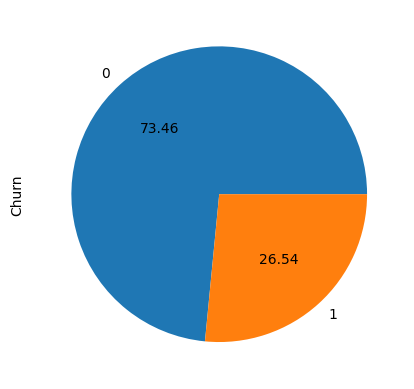

In [7]:
y.value_counts().plot.pie(autopct="%.2f")

In [8]:
data['TotalCharges'].head()

0      29.85
1    1889.50
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: float64

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [10]:
model = LogisticRegression(max_iter=500,random_state=42)
model.fit(X_train,y_train)

LogisticRegression(max_iter=500, random_state=42)

In [11]:
y_pred = model.predict(X_test)

In [12]:
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

In [13]:
accuracy, report

(0.8076650106458482,
 '              precision    recall  f1-score   support\n\n           0       0.85      0.89      0.87      1035\n           1       0.66      0.57      0.61       374\n\n    accuracy                           0.81      1409\n   macro avg       0.76      0.73      0.74      1409\nweighted avg       0.80      0.81      0.80      1409\n')

In [14]:
print("Evaluation Metrics for Logistic Regression")

print(accuracy)

print(report)

Evaluation Metrics for Logistic Regression
0.8076650106458482
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

